# Clasificación multiclase

In [132]:
import os
import pickle
import numpy as np
import pandas as pd

from matplotlib import pyplot
from scipy import optimize

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

%matplotlib inline

## 1 Clasificación multiclase



### 1.1 Dataset


In [133]:
# ============================================================
# CIFAR-10
# ============================================================

input_layer_size = 32 * 32 * 3
num_labels = 10

DATASET_PATH = './cifar-10-batches-py'

batch_files = [
    'data_batch_1',
    'data_batch_2',
    'data_batch_3',
    'data_batch_4',
    'data_batch_5'
]


def load_cifar_batch(filename):

    filepath = os.path.join(
        DATASET_PATH,
        filename
    )

    with open(filepath, 'rb') as f:
        batch = pickle.load(
            f,
            encoding='bytes'
        )

    X_batch = batch[b'data']
    y_batch = np.array(batch[b'labels'])

    return X_batch, y_batch


# Listas para almacenar los cinco batches
X_batches = []
y_batches = []


# Cargar data_batch_1 ... data_batch_5
for batch_file in batch_files:

    X_batch, y_batch = load_cifar_batch(
        batch_file
    )

    X_batches.append(X_batch)
    y_batches.append(y_batch)


# Unir los cinco batches
X = np.concatenate(
    X_batches,
    axis=0
)

y = np.concatenate(
    y_batches,
    axis=0
)

m = y.size

print("X.shape:", X.shape)
print("y.shape:", y.shape)
print("m:", m)

X.shape: (50000, 3072)
y.shape: (50000,)
m: 50000


In [134]:
# Balance del dataset completo
print("Distribución de clases (dataset completo):")
conteo = pd.Series(y).value_counts().sort_index()
conteo.index = class_names
print(conteo)

Distribución de clases (dataset completo):
airplane      5000
automobile    5000
bird          5000
cat           5000
deer          5000
dog           5000
frog          5000
horse         5000
ship          5000
truck         5000
Name: count, dtype: int64


In [135]:
print(os.getcwd())
print(os.path.exists('./cifar-10-batches-py'))

C:\externo\2_study\univer\sis420\lab\lab5
True


In [136]:
print("Primeras filas de X:")
print(X[:5])

print("\nPrimeras etiquetas:")
print(y[:20])

print("\nForma de X:")
print(X.shape)

print("\nForma de y:")
print(y.shape)

Primeras filas de X:
[[ 59  43  50 ... 140  84  72]
 [154 126 105 ... 139 142 144]
 [255 253 253 ...  83  83  84]
 [ 28  37  38 ...  28  37  46]
 [170 168 177 ...  82  78  80]]

Primeras etiquetas:
[6 9 9 4 1 1 2 7 8 3 4 7 7 2 9 9 9 3 2 6]

Forma de X:
(50000, 3072)

Forma de y:
(50000,)


### 1.2 Visualización de los datos


In [137]:
# Nombres de las clases de CIFAR-10

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(class_names)
def displayData(X, y=None, figsize=(10, 10)):

    # Número de imágenes
    m = X.shape[0]

    # Cuadrícula
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(
        display_rows,
        display_cols,
        figsize=figsize
    )

    ax_array = np.array(ax_array).ravel()

    for i, ax in enumerate(ax_array):

        if i < m:

            # CIFAR-10:
            # 3072 = 3 × 32 × 32
            image = X[i].reshape(
                3, 32, 32
            ).transpose(
                1, 2, 0
            )

            # Los datos originales están entre 0 y 255
            image = image / 255.0

            ax.imshow(image)

            # Si proporcionamos las etiquetas,
            # mostrar el nombre de la clase.
            if y is not None:
                ax.set_title(
                    class_names[y[i]],
                    fontsize=8
                )

        ax.axis('off')

    pyplot.tight_layout()
    pyplot.show()

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


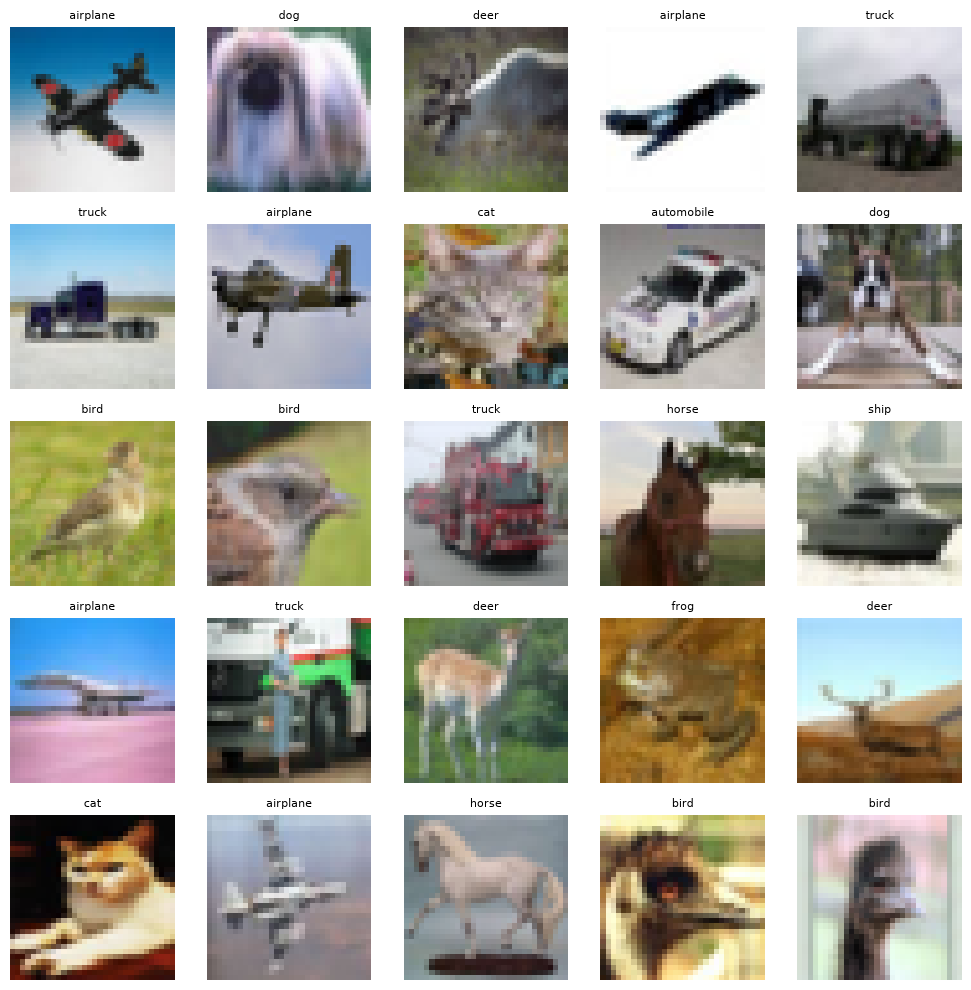

In [138]:
# Selecciona aleatoriamente 25 puntos de datos para mostrar

rand_indices = np.random.choice(
    m,
    25,
    replace=False
)

sel = X[rand_indices, :]
sel_y = y[rand_indices]

displayData(
    sel,
    sel_y
)

### 1.3 Vectorización de regresión logística


In [139]:
# valores de prueba para los parámetros theta
theta_t = np.array([-2, -1, 1, 2], dtype=float)

# valores de prueba para las entradas
X_t = np.concatenate([np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F')/10.0], axis=1)
print(X_t)
# valores de testeo para las etiquetas
y_t = np.array([1, 0, 1, 0, 1])

# valores de testeo para el parametro de regularizacion
lambda_t = 3

[[1.  0.1 0.6 1.1]
 [1.  0.2 0.7 1.2]
 [1.  0.3 0.8 1.3]
 [1.  0.4 0.9 1.4]
 [1.  0.5 1.  1.5]]


<a id="section1"></a>
#### 1.3.1 Vectorización de la funcion de costo


#### 1.3.2 Vectorización del gradiente



In [140]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-z))

In [141]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo de usar theta como parámetro para la regresión logística regularizada y
    el gradiente del costo w.r.t. a los parámetros.

    Parametros
    ----------
    theta : array_like
        Parametro theta de la regresion logistica. Vector de la forma(shape) (n, ). n es el numero de caracteristicas
        incluida la intercepcion

    X : array_like
        Dataset con la forma(shape) (m x n). m es el numero de ejemplos, y n es el numero de
        caracteristicas (incluida la intercepcion).

    y : array_like
        El conjunto de etiquetas. Un vector con la forma (shape) (m, ). m es el numero de ejemplos

    lambda_ : float
        Parametro de regularización.

    Devuelve
    -------
    J : float
        El valor calculado para la funcion de costo regularizada.

    grad : array_like
        Un vector de la forma (shape) (n, ) que es el gradiente de la
        función de costo con respecto a theta, en los valores actuales de theta..
    """
    # Inicializa algunos valores utiles
    m = y.size

    # convierte las etiquetas a valores enteros si son boleanos
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    temp = theta
    temp[0] = 0

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    return J, grad

#### 1.3.3 Vectorización regularizada de la regresión logística
</div>


In [142]:
J, grad = lrCostFunction(theta_t, X_t, y_t, lambda_t)

print('Costo         : {:.6f}'.format(J))
print('Costo esperadot: 2.534819')
print('-----------------------')
print('Gradientes:')
print(' [{:.6f}, {:.6f}, {:.6f}, {:.6f}]'.format(*grad))
print('Gradientes esperados:')
print(' [0.146561, -0.548558, 0.724722, 1.398003]');

Costo         : 2.534819
Costo esperadot: 2.534819
-----------------------
Gradientes:
 [0.146561, -0.548558, 0.724722, 1.398003]
Gradientes esperados:
 [0.146561, -0.548558, 0.724722, 1.398003]


<a id="section2"></a>
### 1.4 Clasificacion One-vs-all
<a id="oneVsAll"></a>

X_train: (40000, 3072)
X_test: (10000, 3072)
X_train min/max: 0.0 1.0

Distribución en entrenamiento:
0    4000
1    4000
2    4000
3    4000
4    4000
5    4000
6    4000
7    4000
8    4000
9    4000
Name: count, dtype: int64

Distribución en prueba:
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: count, dtype: int64


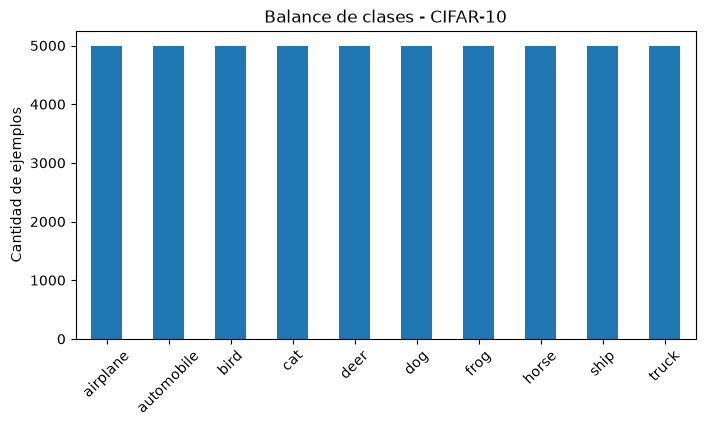

In [143]:
# Normalización + split (va ANTES de llamar a oneVsAll)
X = X.astype(float) / 255.0

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_train min/max:", X_train.min(), X_train.max())

print("\nDistribución en entrenamiento:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nDistribución en prueba:")
print(pd.Series(y_test).value_counts().sort_index())
pyplot.figure(figsize=(8,4))
conteo.plot(kind='bar')
pyplot.ylabel('Cantidad de ejemplos')
pyplot.title('Balance de clases - CIFAR-10')
pyplot.xticks(rotation=45)
pyplot.show()

In [144]:
def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    cost_history = {}

    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        y_c = (y == c)
        costos_c = []

        def callback(theta_k, X=X, y_c=y_c, lambda_=lambda_, costos_c=costos_c):
            J, _ = lrCostFunction(theta_k, X, y_c, lambda_)
            costos_c.append(J)

        options = {'maxiter': 50}
        res = optimize.minimize(lrCostFunction, initial_theta, (X, y_c, lambda_),
                                 jac=True, method='CG', options=options, callback=callback)

        all_theta[c] = res.x
        cost_history[c] = costos_c
        print(f'Clase {c}: costo final = {costos_c[-1]:.6f}' if costos_c else f'Clase {c}: sin historial')

    return all_theta, cost_history

In [145]:
lambda_ = 0.1
all_theta, cost_history = oneVsAll(X_train, y_train, num_labels, lambda_)

Clase 0: costo final = 0.257788
Clase 1: costo final = 0.235605
Clase 2: costo final = 0.286871
Clase 3: costo final = 0.288537
Clase 4: costo final = 0.282995
Clase 5: costo final = 0.280390
Clase 6: costo final = 0.249323
Clase 7: costo final = 0.254988
Clase 8: costo final = 0.234033
Clase 9: costo final = 0.240065


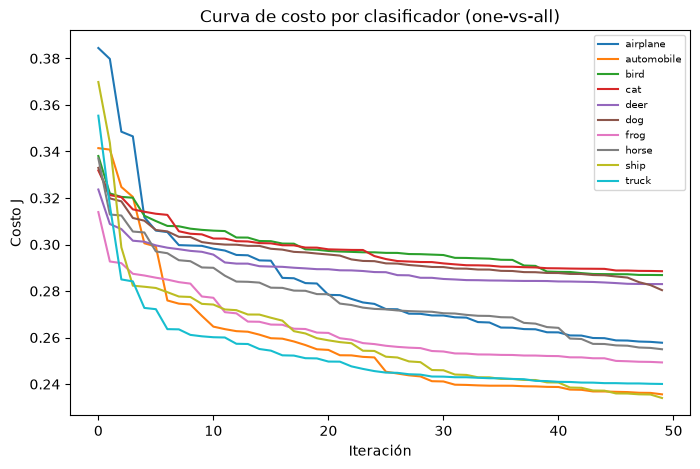

In [146]:
pyplot.figure(figsize=(8, 5))
for c in range(num_labels):
    pyplot.plot(cost_history[c], label=class_names[c])
pyplot.xlabel('Iteración')
pyplot.ylabel('Costo J')
pyplot.title('Curva de costo por clasificador (one-vs-all)')
pyplot.legend(fontsize=7)
pyplot.show()

<a id="section3"></a>
#### 1.4.1 Prediccion One-vs-all


In [147]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada ejemplo en la matriz X.
    Tenga en cuenta que X contiene los ejemplos en filas.
    all_theta es una matriz donde la i-ésima fila es un vector theta de regresión logística entrenada para la i-ésima clase.
    Debe establecer p en un vector de valores de 0..K-1 (por ejemplo, p = [0, 2, 0, 1]
    predice clases 0, 2, 0, 1 para 4 ejemplos).

    Parametros
    ----------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        and n is number of features without the bias.

    X : array_like
        Data points to predict their labels. This is a matrix of shape
        (m x n) where m is number of data points to predict, and n is number
        of features without the bias term. Note we add the bias term for X in
        this function.

    Devuelve
    -------
    p : array_like
        The predictions for each data point in X. This is a vector of shape (m, ).
    """

    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

(10000, 3072)
Precisión del conjunto de prueba: 40.85%
Predicciones : [8 3 8 3 8 2 8 5 9 8 7 2]
Reales       : [8 2 8 8 8 4 8 4 2 8 7 2]


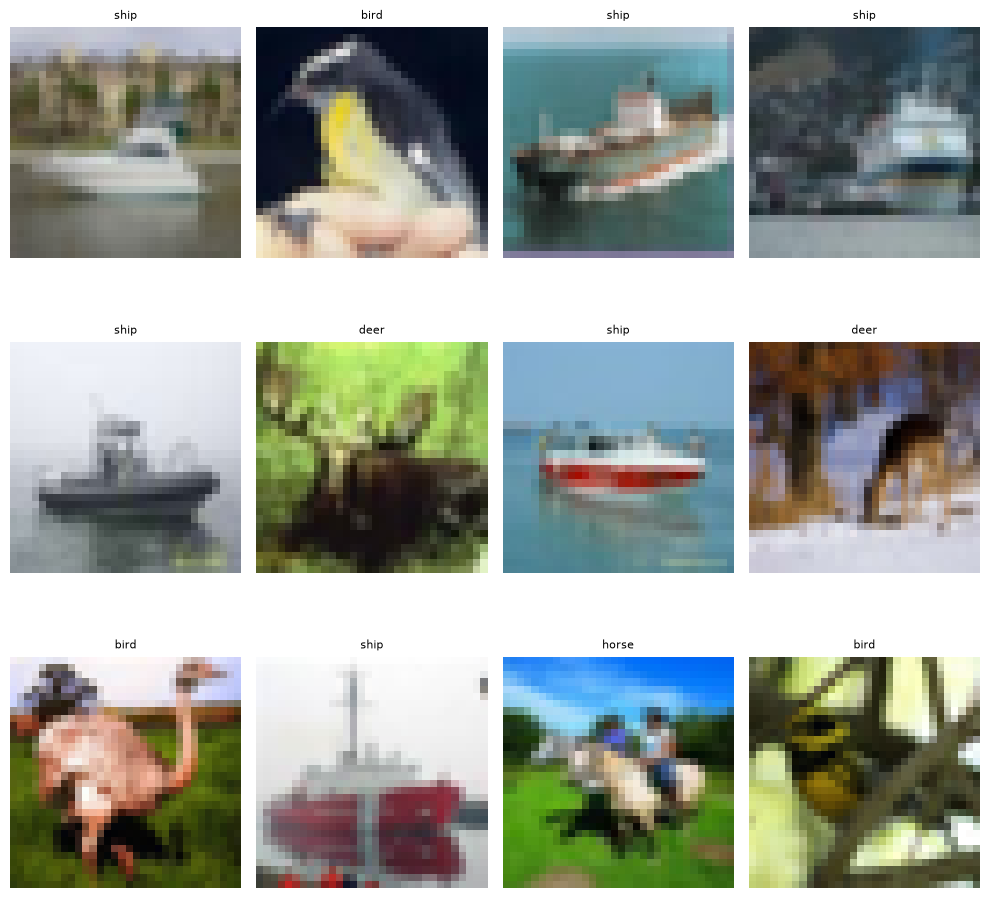

In [148]:
print(X_test.shape)

pred = predictOneVsAll(all_theta, X_test)
print('Precisión del conjunto de prueba: {:.2f}%'.format(np.mean(pred == y_test) * 100))

XPrueba = X_test[2001:2013, :].copy()
yPrueba = y_test[2001:2013]

p = predictOneVsAll(all_theta, XPrueba)
print('Predicciones :', p)
print('Reales       :', yPrueba)

displayData(XPrueba*255.0, yPrueba)

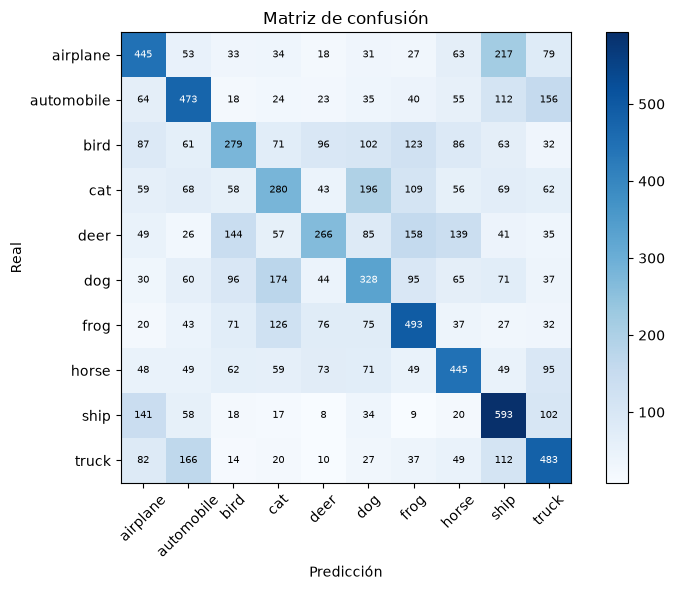

In [149]:

cm = confusion_matrix(y_test, pred)

pyplot.figure(figsize=(8, 6))
pyplot.imshow(cm, cmap='Blues')
pyplot.colorbar()
pyplot.xticks(range(10), class_names, rotation=45)
pyplot.yticks(range(10), class_names)
pyplot.xlabel('Predicción')
pyplot.ylabel('Real')
pyplot.title('Matriz de confusión')

# números dentro de cada celda
for i in range(10):
    for j in range(10):
        pyplot.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=7)

pyplot.tight_layout()
pyplot.show()